# Neural Network

In [6]:
# pylint: disable=missing-module-docstring
import math
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from abc import abstractmethod
from typing import Tuple

np.random.seed(13)

## Load Data

In [7]:
def load_data_npy():
    # pylint: disable=missing-function-docstring
    x = np.load("data/X.npy")
    y = np.load("data/y.npy")
    return x, y

def split_data(data: NDArray, rate: float) -> Tuple[NDArray, NDArray]:
    # pylint: disable=missing-function-docstring
    indices = np.random.permutation(data.shape[0])
    m = int(data.shape[0] * rate)
    d1_idx = indices[:m]
    d2_idx = indices[m:]
    return data[d1_idx], data[d2_idx]

x_data, y_data = load_data_npy()
x_data = x_data[:1000]
y_data = y_data[:1000]
x_train, x_test = split_data(x_data, 0.8)
y_train, y_test = split_data(y_data, 0.8)

print (f'Shape: x_data {x_data.shape}, y_data {y_data.shape}')
print (f'Shape: x_train {x_train.shape}, y_train {y_train.shape}')
print (f'Shape: x_test {x_test.shape}, y_test {y_test.shape}')
# print ('The first element of x is: ', x_train[0])

Shape: x_data (1000, 400), y_data (1000, 1)
Shape: x_train (800, 400), y_train (800, 1)
Shape: x_test (200, 400), y_test (200, 1)


## Visualizate the data

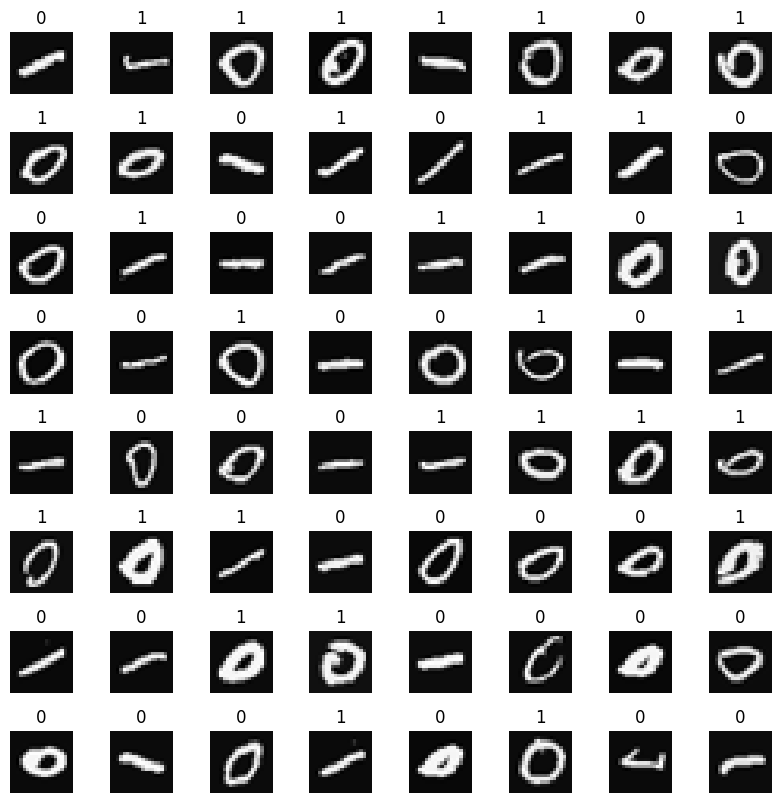

In [4]:
def visualize_data(x: NDArray, y: NDArray):
    # pylint: disable=missing-function-docstring
    m, _ = x.shape

    fig, axes = plt.subplots(8,8, figsize=(8,8))
    fig.tight_layout(pad=0.1)

    for _,ax in enumerate(axes.flat):
        # Select random indices
        random_index = np.random.randint(m)
        
        # Select rows corresponding to the random indices and
        # reshape the image
        x_random_reshaped = x[random_index].reshape((20,20))
        
        # Display the image
        ax.imshow(x_random_reshaped, cmap='gray')
        
        # Display the label above the image
        ax.set_title(y[random_index,0])
        ax.set_axis_off()

visualize_data(x_train, y_train)

Epoch          0: Cost 1.26162271
Epoch        300: Cost 0.96824777
Epoch        600: Cost 0.81171605
Epoch        900: Cost 0.74132823
Epoch       1200: Cost 0.71245594
Epoch       1500: Cost 0.70103206
Epoch       1800: Cost 0.69654930
Epoch       2100: Cost 0.69477854
Epoch       2400: Cost 0.69406302
Epoch       2700: Cost 0.69375826
shape: p_hat (200, 1), y (200, 1)
postive counter: 80
==== Score ====
Y: positive counter: 98, negative counter: 102
Accuracy: 0.5300
TP: 42, FP: 38, TN: 64, FN: 56
Precision: 0.5250
Recall: 0.4286
Accuracy: 0.5300
F1 Score: 0.4719


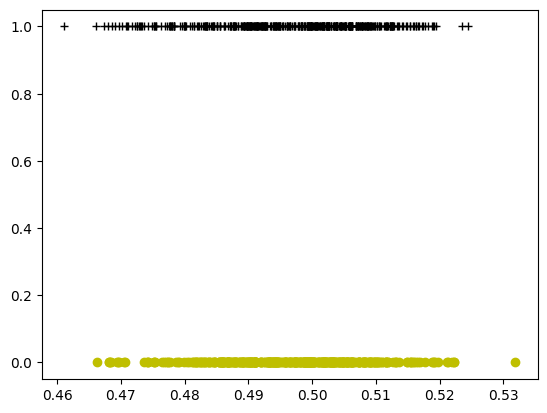

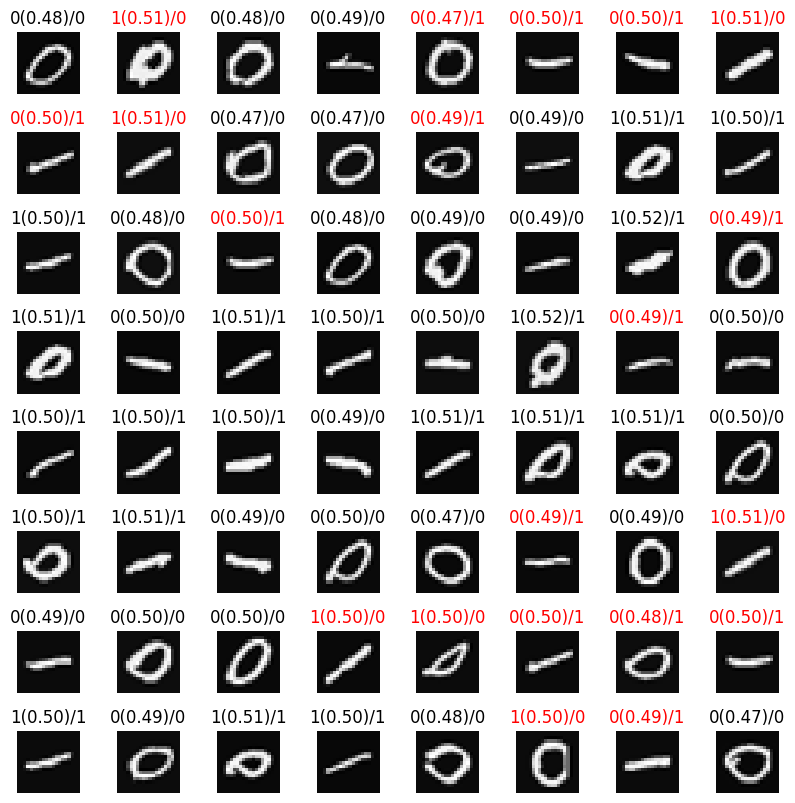

In [14]:
class LossFunction:
    # pylint: disable=missing-class-docstring
    
    @abstractmethod
    def compute_loss(self, p_hat: NDArray, y: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        pass

    @abstractmethod
    def derivative(self, p_hat: NDArray, y: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        pass


class BinaryCrossEntropy(LossFunction):
    # pylint: disable=missing-class-docstring

    def compute_loss(self, p_hat: NDArray, y: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        epsilon = 1e-7
        p_hat_clipped = np.clip(p_hat, epsilon, 1. - epsilon)
        loss = -(y * np.log(p_hat_clipped) + (1 - y) * np.log(1 - p_hat_clipped))
        return loss

    def derivative(self, p_hat: NDArray, y: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        return (p_hat - y) / (p_hat * (1 - p_hat))

class ActivationFunction:
    # pylint: disable=missing-class-docstring

    def __init__(self):
        # pylint: disable=missing-function-docstring
        pass

    def compute_f(self, x, w, b) -> NDArray:
        # pylint: disable=missing-function-docstring
        z = np.dot(x, w) + b
        return self.activation(z)

    @abstractmethod
    def activation(self, z: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        pass

    @abstractmethod
    def derivative(self, a: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        pass

class SigmoidActivation(ActivationFunction):
    # pylint: disable=missing-class-docstring

    def activation(self, z: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        z = np.clip(z, -500, 500)
        g = 1 / (1 + np.exp(-z))
        return g

    def derivative(self, a: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        return a * (1 - a)

class ReluActivation(ActivationFunction):
    # pylint: disable=missing-class-docstring

    def activation(self, z: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        return np.maximum(0, z)

    def derivative(self, a: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        return np.where(a > 0, 1, 0)

class NeuralLayer:
    # pylint: disable=missing-class-docstring

    def __init__(self, units: int, act_function: ActivationFunction, lr: float = 0.001, lambda_: float = 0):
        # pylint: disable=missing-function-docstring
        self.units = units
        self.act_function = act_function
        self.lr = lr
        self.lambda_ = lambda_
        self.w = None
        self.b = None
        self.a_in = None
        self.a_out = None
    
    def set_weights(self, w: NDArray, b: NDArray):
        # pylint: disable=missing-function-docstring
        self.w = w
        self.b = b
    
    def init_weights(self, dim_in: int):
        # pylint: disable=missing-function-docstring
        self.w = np.random.randn(dim_in, self.units) * np.sqrt(2. / dim_in)
        # self.w = 0.5 * (np.random.randn(dim_in, self.units) - 0.5)
        self.b = np.random.randn(self.units)
    
    def weights(self) -> Tuple[NDArray, NDArray]:
        # pylint: disable=missing-function-docstring
        return self.w, self.b

    def forward(self, a_in: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        self.a_in = a_in
        n = a_in.shape[1]
        if self.w is None or self.b is None:
            self.init_weights(n)
        self.a_out = self.act_function.compute_f(a_in, self.w, self.b)
        return self.a_out
    
    def backward(self, da: NDArray):
        # pylint: disable=missing-function-docstring

        dz = da * self.act_function.derivative(self.a_out)

        m = self.a_in.shape[0]
        dj_dw = np.dot(self.a_in.T, dz) / m
        if self.lambda_ != 0:
            dj_dw += (self.lambda_ / m) * self.w
        dj_db = np.sum(dz, axis = 0) / m
        self.w -= self.lr * dj_dw
        self.b -= self.lr * dj_db        
        
        
        bwd_dz = np.dot(dz, self.w.T)
        # print(f'shape: dz {dz.shape}, w {self.w.shape}, dj_dw {dj_dw.shape}, b {self.b.shape}, dj_db {dj_db.shape}， bwd_dz {bwd_dz.shape}')
        return bwd_dz

class NeuralNetwork:
    # pylint: disable=missing-class-docstring

    def __init__(self):
        self.layers: list[NeuralLayer] = []
        self.loss_function = BinaryCrossEntropy()
    
    def add_layer(self, layer: NeuralLayer):
        # pylint: disable=missing-function-docstring
        self.layers.append(layer)
    
    def get_layers(self) -> list[NeuralLayer]:
        # pylint: disable=missing-function-docstring
        return self.layers

    def compute_cost(self, p_hat: NDArray, y: NDArray, lambda_: float = 0) -> Tuple[float, NDArray]:
        # pylint: disable=missing-function-docstring

        if (len(self.layers) == 0):
            return [0, np.zeros(0)]

        loss = self.loss_function.compute_loss(p_hat, y)
        cost_without_reg = np.mean(loss)

        reg_cost = 0
        w_num = 0
        for layer in self.layers:
            w, _ = layer.weights()
            reg_cost += sum(np.square(w.flatten()).flatten())
            w_num += w.shape[1]

        cost = cost_without_reg + (lambda_ / (2 * w_num)) * reg_cost
        return cost, loss

    def forward(self, x) -> NDArray:
        # pylint: disable=missing-function-docstring
        a = x
        for layer in self.layers:
            a = layer.forward(a)
        
        return a
    
    def backward(self, p_hat: NDArray, y: NDArray):
        # pylint: disable=missing-function-docstring
        da = self.loss_function.derivative(p_hat, y)
        for layer in reversed(self.layers):
            da = layer.backward(da)

    def fit(self, x: NDArray, y: NDArray, epochs: int, lambda_: float = 0) -> NDArray:
        # pylint: disable=missing-function-docstring
        num_prints = max(1, math.ceil(epochs / 10))
        for i in range(epochs):
            p_hat = self.forward(x)
            cost, _ = self.compute_cost(p_hat, y, lambda_)
            if i % num_prints == 0:
                print(f'Epoch {i:10d}: Cost {cost:.8f}')
            
            self.backward(p_hat, y)

        return p_hat

    def predict(self, x) -> NDArray:
        # pylint: disable=missing-function-docstring
        p_hat = self.forward(x)
        return p_hat
        
nn = NeuralNetwork()
nn.add_layer(NeuralLayer(25, SigmoidActivation(), 0.001))
nn.add_layer(NeuralLayer(15, SigmoidActivation(), 0.001))
nn.add_layer(NeuralLayer(1, SigmoidActivation(), 0.001))
def train(x: NDArray, y: NDArray):
    # pylint: disable=missing-function-docstring
    epochs = 3000
    p_hat = nn.fit(x, y, epochs)
    # print(f'X shape: {x.shape}')
    # print(f'y shape: {y.shape}')
    # print(f'p_hat shape: {p_hat.shape}')
    # layers = nn.get_layers()
    # for i, layer in enumerate(layers):
    #     w, b = layer.weights()
    #     print(f'[Layer {i:2d}] w shape: {w.shape}, b shape: {b.shape}')

    plot_data(p_hat, y[:,0], pos_label="y=1", neg_label="y=0")

def plot_data(x, y, pos_label="y=1", neg_label="y=0"):
    # pylint: disable=missing-function-docstring
    positive = y == 1
    negative = y == 0
    # Plot examples
    plt.plot(x[positive, 0], y[positive], 'k+', label=pos_label)
    plt.plot(x[negative, 0], y[negative], 'yo', label=neg_label)

def print_score(p_hat: NDArray, y: NDArray):
    # pylint: disable=missing-function-docstring
    tp = np.sum(np.logical_and(p_hat == 1, y == 1))
    fp = np.sum(np.logical_and(p_hat == 1, y == 0))
    tn = np.sum(np.logical_and(p_hat == 0, y == 0))
    fn = np.sum(np.logical_and(p_hat == 0, y == 1))
    accuracy = (tp + tn) / (tp + fp + tn + fn)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * (precision * recall) / (precision + recall)

    print('==== Score ====')
    print(f'Y: positive counter: {np.sum(y == 1)}, negative counter: {np.sum(y == 0)}')
    print(f'Accuracy: {(tp + tn) / (tp + fp + tn + fn):.4f}')
    print(f'TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'F1 Score: {f1:.4f}')

def test_predict(x: NDArray, y: NDArray):
    # pylint: disable=missing-function-docstring
    p_hat = nn.predict(x)
    print(f'shape: p_hat {p_hat.shape}, y {y.shape}')
    p = np.where(p_hat > 0.5, 1, 0)

    postive_idx = p_hat > 0.5
    print(f'postive counter: {np.sum(postive_idx)}')
    
    print_score(p, y)

    m, _ = x.shape
    fig, axes = plt.subplots(8,8, figsize=(8,8))
    fig.tight_layout(pad=0.1)
    for _,ax in enumerate(axes.flat):
        # Select random indices
        random_index = np.random.randint(m)
        
        # Select rows corresponding to the random indices and
        # reshape the image
        x_random_reshaped = x[random_index].reshape((20,20))
        
        # Display the image
        ax.imshow(x_random_reshaped, cmap='gray')
        
        # Display the label above the image
        ax.set_title(
            f'{int(p[random_index,0])}({p_hat[random_index,0]:.2f})/{y[random_index,0]}',
            color = f'{'black' if p[random_index,0] == y[random_index,0] else 'red'}'
        )
        ax.set_axis_off()

# test_neural_network()
train(x_train, y_train)
test_predict(x_test, y_test)
